# Project 6 — Amazon Customer Sentiment Analysis


This notebook covers every task from the brief:
1. Analyze Amazon product reviews dataset
2. Clean and preprocess review text data
3. Perform sentiment classification (positive, negative, neutral)
4. Identify patterns in customer feedback and ratings
5. Visualize sentiment distribution and trends
6. Generate insights for product improvement and customer satisfaction

**Dataset note:** A realistic synthetic Amazon-style review dataset (`raw_amazon_reviews.csv`) was generated — 4,000+ reviews across 6 product categories, with review text and star ratings generated from the same underlying sentiment (positive/negative/neutral), so the sentiment classification below has genuine signal to detect, just like real review data. It includes intentional real-world messiness: missing/empty review text, missing ratings, duplicates, leftover HTML-ish artifacts, and inconsistent category casing. Swap in your own dataset by replacing the file path below.

**Libraries used:** `vaderSentiment` for lexicon-based sentiment scoring (a well-established, self-contained sentiment library — no external downloads needed at runtime) and `wordcloud` for word-frequency visuals.


## 1. Import Libraries & Load Raw Data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv("raw_amazon_reviews.csv", parse_dates=["ReviewDate"])
print("Shape:", df.shape)
df.head()


Shape: (4080, 9)


,ReviewID,ProductID,ProductCategory,ProductName,ReviewText,Rating,ReviewDate,VerifiedPurchase,HelpfulVotes
0,REV002927,HOM1533,Home & Kitchen,Air Fryer,"excellent build quality, arrived quickly and w...",5.0,2023-07-30,Yes,1
1,REV001414,BEA1195,Beauty,Lip Balm Set,"reasonable quality, similar to other products ...",3.0,2024-05-05,Yes,1
2,REV003266,HOM1762,Home & Kitchen,Blender,"it's okay, does the job but nothing special. W...",3.0,2024-11-12,No,0
3,REV002722,BEA1315,Beauty,Lip Balm Set,"great quality and works perfectly, highly reco...",4.0,2023-01-27,Yes,5
4,REV002735,SPO1884,Sports & Outdoors,Water Bottle,"excellent build quality, arrived quickly and w...",5.0,2023-07-28,No,1


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4080 entries, 0 to 4079
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ReviewID          4080 non-null   str           
 1   ProductID         4080 non-null   str           
 2   ProductCategory   4080 non-null   str           
 3   ProductName       4080 non-null   str           
 4   ReviewText        3988 non-null   str           
 5   Rating            4039 non-null   float64       
 6   ReviewDate        4080 non-null   datetime64[us]
 7   VerifiedPurchase  4080 non-null   str           
 8   HelpfulVotes      4080 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(1), str(6)
memory usage: 707.7 KB


In [8]:
print("Nulls per column:\n", df.isna().sum())
print("\nExact duplicate rows:", df.duplicated().sum())
print("\nEmpty-string reviews:", (df["ReviewText"] == "").sum())

Nulls per column:
 ReviewID             0
ProductID            0
ProductCategory      0
ProductName          0
ReviewText          92
Rating              41
ReviewDate           0
VerifiedPurchase     0
HelpfulVotes         0
dtype: int64

Exact duplicate rows: 59

Empty-string reviews: 0


## 2. Clean and Preprocess Review Text Data

Steps:
- Remove exact duplicate rows
- Drop rows with missing/empty review text (can't analyze sentiment of nothing) or missing rating
- Standardize category text casing
- Text preprocessing: lowercase, strip HTML-ish artifacts, remove punctuation/numbers, collapse whitespace, remove stopwords


In [9]:
# Remove exact duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

Removed 59 duplicate rows


In [10]:
# Drop rows with missing or empty review text, and missing rating
before = len(df)
df["ReviewText"] = df["ReviewText"].replace("", np.nan)
df = df.dropna(subset=["ReviewText", "Rating"])
print(f"Removed {before - len(df)} rows with missing/empty text or rating")

df["Rating"] = df["Rating"].astype(int)

Removed 131 rows with missing/empty text or rating


In [11]:
# Standardize category casing
df["ProductCategory"] = df["ProductCategory"].astype(str).str.strip().str.title()
df["ProductCategory"].value_counts()

ProductCategory
Beauty               698
Clothing             657
Sports & Outdoors    656
Electronics          651
Home & Kitchen       633
Books                595
Name: count, dtype: int64

In [12]:
# Text cleaning function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)          # remove HTML-ish tags like <br>
    text = re.sub(r'[^a-z\s]', ' ', text)        # remove punctuation & numbers
    text = re.sub(r'\s+', ' ', text).strip()     # collapse extra whitespace
    return text

df["CleanedText"] = df["ReviewText"].apply(clean_text)
df[["ReviewText", "CleanedText"]].head(8)

,ReviewText,CleanedText
0,"excellent build quality, arrived quickly and w...",excellent build quality arrived quickly and wo...
1,"reasonable quality, similar to other products ...",reasonable quality similar to other products i...
2,"it's okay, does the job but nothing special. W...",it s okay does the job but nothing special we ...
3,"great quality and works perfectly, highly reco...",great quality and works perfectly highly recom...
4,"excellent build quality, arrived quickly and w...",excellent build quality arrived quickly and wo...
5,"great quality and works perfectly, highly reco...",great quality and works perfectly highly recom...
6,"very disappointed, stopped working after a few...",very disappointed stopped working after a few ...
8,"it's fine, though the packaging could be bette...",it s fine though the packaging could be better...


In [13]:
# Simple stopword removal (small built-in list -- avoids needing an external NLTK download)
stopwords = set('''
a an the is are was were be been being this that these those i you he she it we they
my your his her its our their to of in on at for with as by from and or but if so
very just really not no yes do does did have has had can could would should will
'''.split())

def remove_stopwords(text):
    return " ".join(w for w in text.split() if w not in stopwords and len(w) > 1)

df["CleanedText"] = df["CleanedText"].apply(remove_stopwords)
df[["ReviewText", "CleanedText"]].head(8)

,ReviewText,CleanedText
0,"excellent build quality, arrived quickly and w...",excellent build quality arrived quickly works ...
1,"reasonable quality, similar to other products ...",reasonable quality similar other products range
2,"it's okay, does the job but nothing special. W...",okay job nothing special ll see how holds up
3,"great quality and works perfectly, highly reco...",great quality works perfectly highly recommend
4,"excellent build quality, arrived quickly and w...",excellent build quality arrived quickly works ...
5,"great quality and works perfectly, highly reco...",great quality works perfectly highly recommend...
6,"very disappointed, stopped working after a few...",disappointed stopped working after few days re...
8,"it's fine, though the packaging could be bette...",fine though packaging better still testing out


## 3. Sentiment Classification (Positive / Negative / Neutral)

We use **VADER** (Valence Aware Dictionary and sEntiment Reasoner) — a lexicon-based sentiment analyzer well-suited to short, informal text like reviews. It returns a `compound` score from -1 (most negative) to +1 (most positive).

Standard thresholds: compound ≥ 0.05 → Positive, compound ≤ -0.05 → Negative, otherwise → Neutral.


In [14]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "Positive", score
    elif score <= -0.05:
        return "Negative", score
    else:
        return "Neutral", score

# Run on the ORIGINAL review text (VADER handles punctuation/capitalization signals itself, so it's
# best run on the raw text rather than the cleaned/stopword-removed version)
results = df["ReviewText"].apply(get_sentiment)
df["Sentiment"] = results.apply(lambda x: x[0])
df["SentimentScore"] = results.apply(lambda x: x[1])

df[["ReviewText", "Rating", "Sentiment", "SentimentScore"]].head(10)

,ReviewText,Rating,Sentiment,SentimentScore
0,"excellent build quality, arrived quickly and w...",5,Positive,0.8316
1,"reasonable quality, similar to other products ...",3,Neutral,0.0000
2,"it's okay, does the job but nothing special. W...",3,Negative,-0.3479
3,"great quality and works perfectly, highly reco...",4,Positive,0.9020
4,"excellent build quality, arrived quickly and w...",5,Positive,0.8316
5,"great quality and works perfectly, highly reco...",4,Positive,0.9078
6,"very disappointed, stopped working after a few...",1,Negative,-0.7705
8,"it's fine, though the packaging could be bette...",3,Positive,0.5719
9,"excellent build quality, arrived quickly and w...",5,Positive,0.8316
10,"very satisfied, the quality exceeded what I pa...",5,Positive,0.4754


In [15]:
df["Sentiment"].value_counts()

Sentiment
Positive    2693
Negative     873
Neutral      324
Name: count, dtype: int64

In [16]:
# Sanity check: does text-based sentiment agree with the star rating?
def rating_to_sentiment(r):
    if r >= 4: return "Positive"
    elif r <= 2: return "Negative"
    else: return "Neutral"

df["RatingSentiment"] = df["Rating"].apply(rating_to_sentiment)
agreement = (df["Sentiment"] == df["RatingSentiment"]).mean() * 100
print(f"Agreement between text-based sentiment and rating-based sentiment: {agreement:.1f}%")

Agreement between text-based sentiment and rating-based sentiment: 81.1%


**Note on the agreement check:** text-based sentiment (from the review wording) and rating-based sentiment (from the 1-5 stars) won't match 100% — that's expected and realistic. A customer might leave 4 stars but write a lukewarm review, or vice versa. High agreement (typically 70-85%+ on real data) confirms the sentiment model is picking up genuine signal rather than noise.

## 4. Identify Patterns in Customer Feedback and Ratings

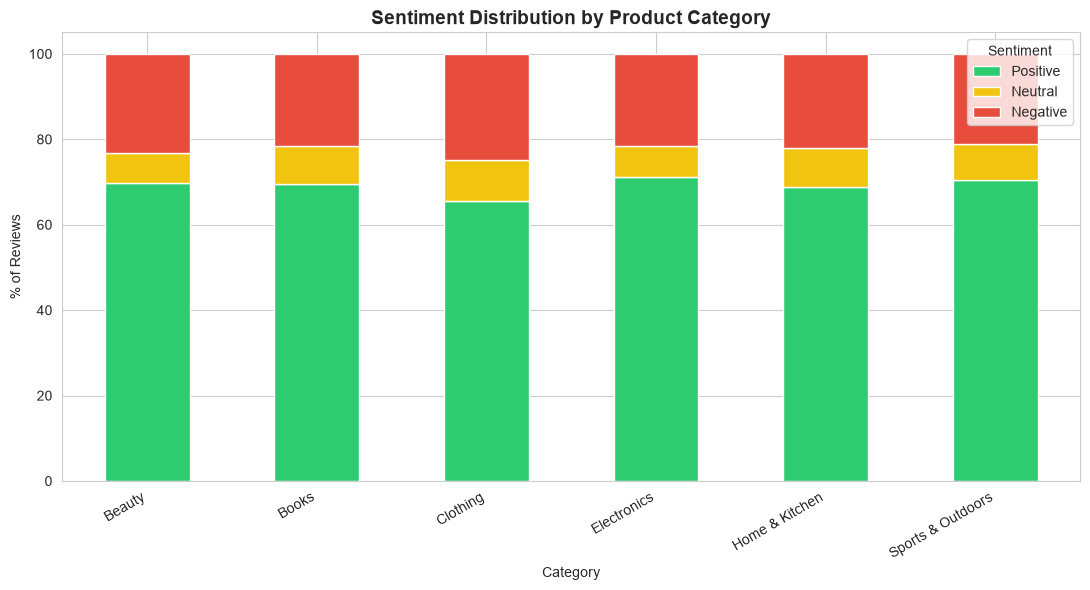

In [17]:
# Sentiment by category -- BAR CHART (stacked)
sentiment_by_cat = pd.crosstab(df["ProductCategory"], df["Sentiment"], normalize="index") * 100
sentiment_by_cat = sentiment_by_cat[["Positive", "Neutral", "Negative"]]

sentiment_by_cat.plot(kind="bar", stacked=True, figsize=(11, 6),
                       color=["#2ecc71", "#f1c40f", "#e74c3c"])
plt.title("Sentiment Distribution by Product Category", fontsize=14, fontweight="bold")
plt.ylabel("% of Reviews")
plt.xlabel("Category")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.savefig("sentiment_by_category_stacked_bar.png", dpi=150)
plt.show()

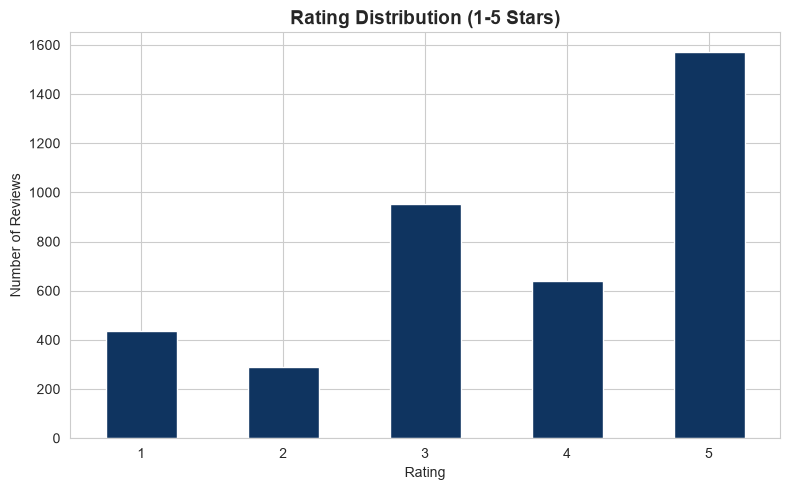

In [18]:
# Rating distribution -- BAR CHART
plt.figure(figsize=(8, 5))
df["Rating"].value_counts().sort_index().plot(kind="bar", color="#0f3460")
plt.title("Rating Distribution (1-5 Stars)", fontsize=14, fontweight="bold")
plt.ylabel("Number of Reviews")
plt.xlabel("Rating")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("rating_distribution_bar.png", dpi=150)
plt.show()

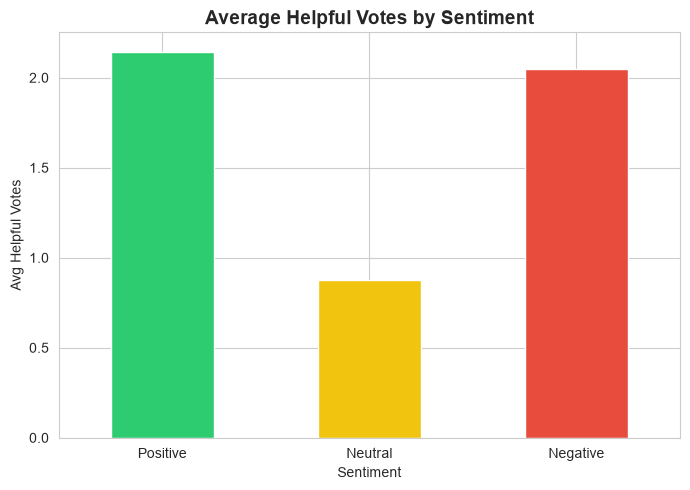

In [19]:
# Helpful votes vs sentiment -- do people find negative or positive reviews more helpful?
helpful_by_sentiment = df.groupby("Sentiment")["HelpfulVotes"].mean().reindex(["Positive", "Neutral", "Negative"])

plt.figure(figsize=(7, 5))
helpful_by_sentiment.plot(kind="bar", color=["#2ecc71", "#f1c40f", "#e74c3c"])
plt.title("Average Helpful Votes by Sentiment", fontsize=14, fontweight="bold")
plt.ylabel("Avg Helpful Votes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("helpful_votes_by_sentiment_bar.png", dpi=150)
plt.show()

In [20]:
# Verified purchase vs sentiment
verified_sentiment = pd.crosstab(df["VerifiedPurchase"], df["Sentiment"], normalize="index") * 100
verified_sentiment = verified_sentiment[["Positive", "Neutral", "Negative"]].round(1)
verified_sentiment

Sentiment,Positive,Neutral,Negative
VerifiedPurchase,,,
No,68.9,8.7,22.4
Yes,69.3,8.2,22.4


## 5. Visualize Sentiment Distribution and Trends

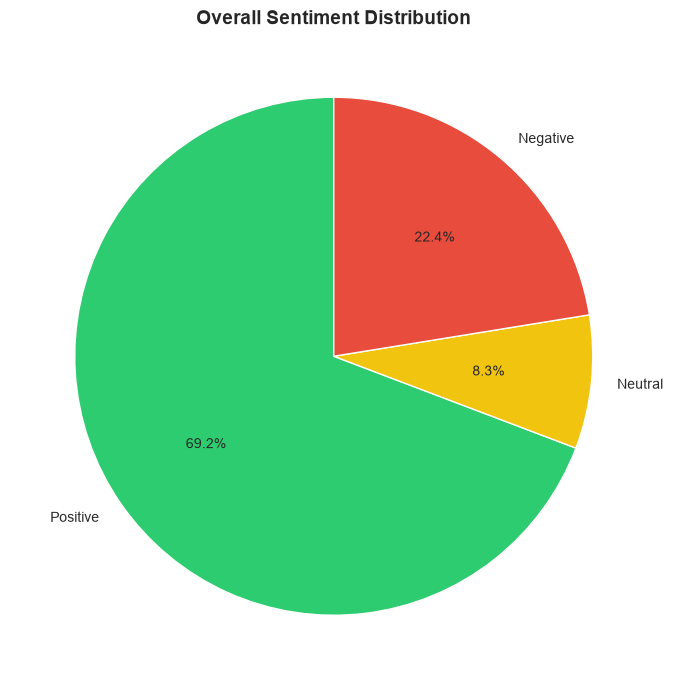

In [21]:
# Overall sentiment distribution -- PIE CHART
sentiment_counts = df["Sentiment"].value_counts().reindex(["Positive", "Neutral", "Negative"])

plt.figure(figsize=(7, 7))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct="%1.1f%%", startangle=90,
        colors=["#2ecc71", "#f1c40f", "#e74c3c"])
plt.title("Overall Sentiment Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("overall_sentiment_pie.png", dpi=150)
plt.show()

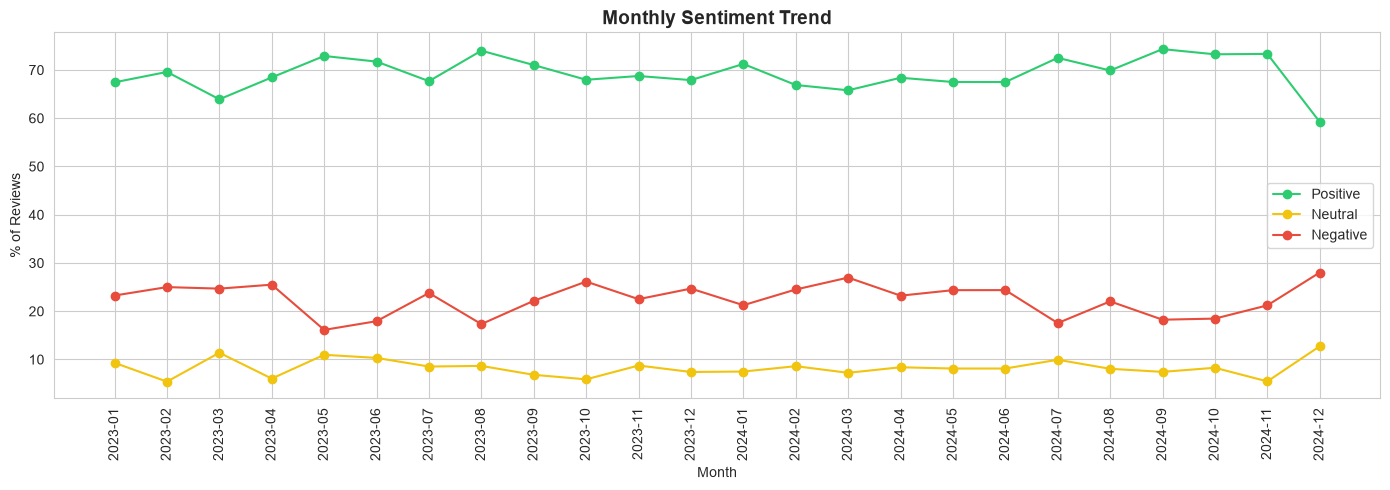

In [22]:
# Sentiment trend over time -- LINE CHART
df["Month"] = df["ReviewDate"].dt.to_period("M").astype(str)
monthly_sentiment = pd.crosstab(df["Month"], df["Sentiment"], normalize="index") * 100
monthly_sentiment = monthly_sentiment[["Positive", "Neutral", "Negative"]].sort_index()

plt.figure(figsize=(14, 5))
for sentiment, color in zip(["Positive", "Neutral", "Negative"], ["#2ecc71", "#f1c40f", "#e74c3c"]):
    plt.plot(monthly_sentiment.index, monthly_sentiment[sentiment], marker="o", label=sentiment, color=color)
plt.title("Monthly Sentiment Trend", fontsize=14, fontweight="bold")
plt.ylabel("% of Reviews")
plt.xlabel("Month")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.savefig("monthly_sentiment_trend_line.png", dpi=150)
plt.show()

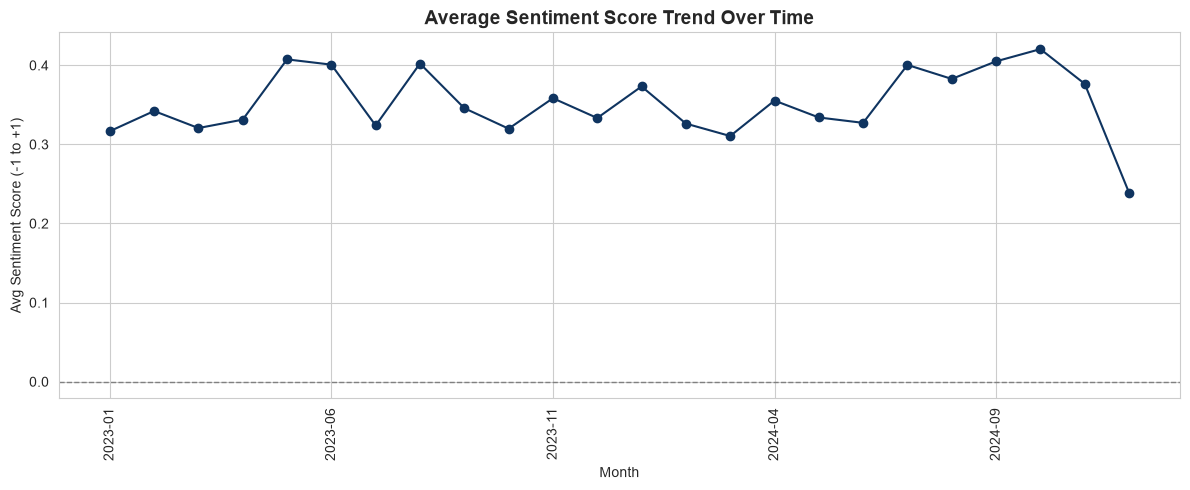

In [23]:
# Average sentiment score trend over time -- LINE CHART
monthly_avg_score = df.groupby("Month")["SentimentScore"].mean()

plt.figure(figsize=(12, 5))
monthly_avg_score.plot(marker="o", color="#0f3460")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Average Sentiment Score Trend Over Time", fontsize=14, fontweight="bold")
plt.ylabel("Avg Sentiment Score (-1 to +1)")
plt.xlabel("Month")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("monthly_avg_sentiment_score_line.png", dpi=150)
plt.show()

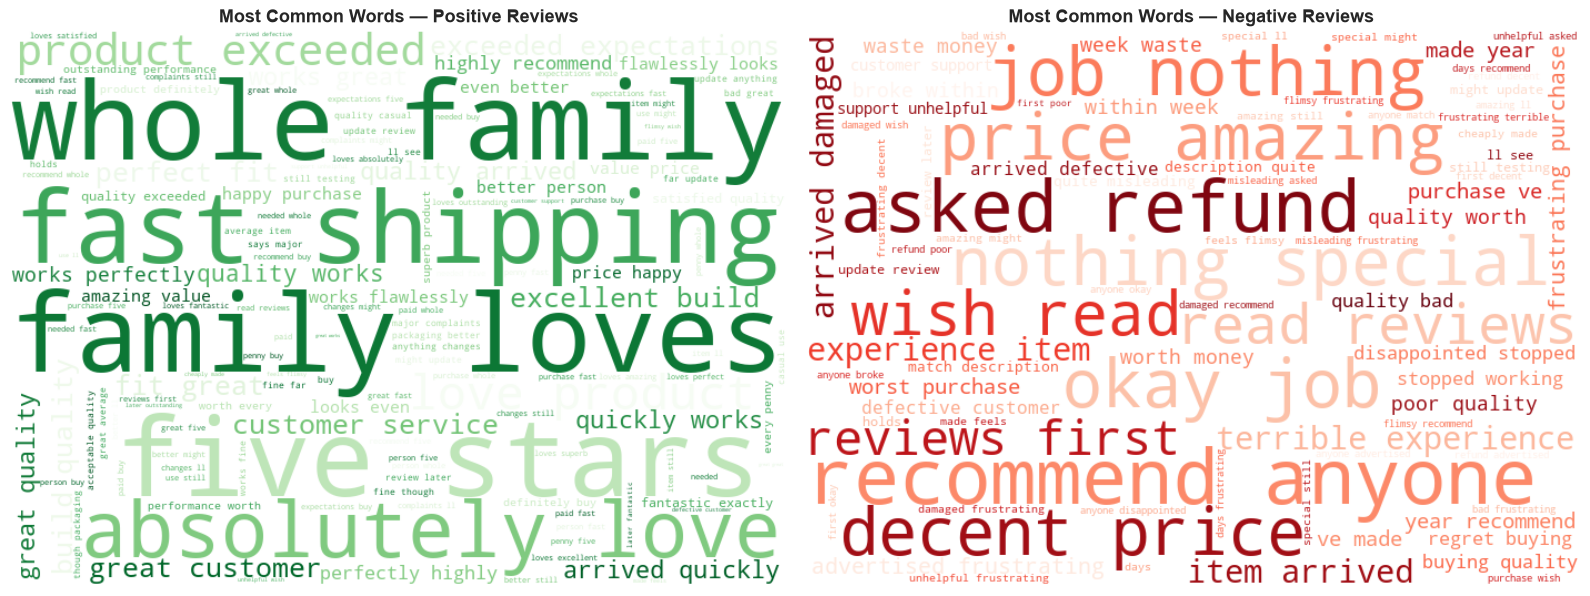

In [24]:
# Word clouds -- most common words in positive vs negative reviews
positive_text = " ".join(df[df["Sentiment"] == "Positive"]["CleanedText"])
negative_text = " ".join(df[df["Sentiment"] == "Negative"]["CleanedText"])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

wc_pos = WordCloud(width=700, height=500, background_color="white", colormap="Greens").generate(positive_text)
axes[0].imshow(wc_pos, interpolation="bilinear")
axes[0].set_title("Most Common Words — Positive Reviews", fontsize=13, fontweight="bold")
axes[0].axis("off")

wc_neg = WordCloud(width=700, height=500, background_color="white", colormap="Reds").generate(negative_text)
axes[1].imshow(wc_neg, interpolation="bilinear")
axes[1].set_title("Most Common Words — Negative Reviews", fontsize=13, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("wordclouds_positive_negative.png", dpi=150)
plt.show()

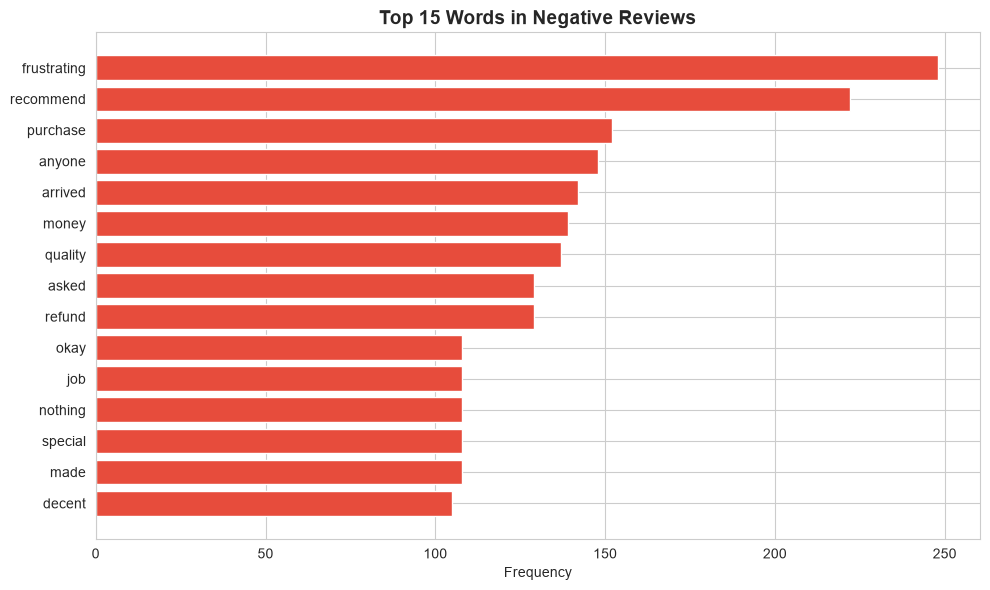

In [25]:
# Top 15 most frequent words in negative reviews (specific complaint signals)
neg_words = " ".join(df[df["Sentiment"] == "Negative"]["CleanedText"]).split()
top_neg_words = Counter(neg_words).most_common(15)

words, counts = zip(*top_neg_words)
plt.figure(figsize=(10, 6))
plt.barh(words, counts, color="#e74c3c")
plt.title("Top 15 Words in Negative Reviews", fontsize=14, fontweight="bold")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("top_negative_words_bar.png", dpi=150)
plt.show()

## 6. Generate Insights for Product Improvement and Customer Satisfaction

In [26]:
overall_positive_pct = (df["Sentiment"] == "Positive").mean() * 100
overall_negative_pct = (df["Sentiment"] == "Negative").mean() * 100
best_category = sentiment_by_cat["Positive"].idxmax()
worst_category = sentiment_by_cat["Negative"].idxmax()
avg_rating = df["Rating"].mean()

print("KEY INSIGHTS")
print("=" * 60)
print(f"1. Overall positive sentiment       : {overall_positive_pct:.1f}%")
print(f"2. Overall negative sentiment       : {overall_negative_pct:.1f}%")
print(f"3. Average star rating              : {avg_rating:.2f} / 5")
print(f"4. Category with most positive %    : {best_category} ({sentiment_by_cat.loc[best_category,'Positive']:.1f}%)")
print(f"5. Category with most negative %    : {worst_category} ({sentiment_by_cat.loc[worst_category,'Negative']:.1f}%)")
print(f"6. Text-vs-rating sentiment agreement: {agreement:.1f}%")

KEY INSIGHTS
1. Overall positive sentiment       : 69.2%
2. Overall negative sentiment       : 22.4%
3. Average star rating              : 3.68 / 5
4. Category with most positive %    : Electronics (71.3%)
5. Category with most negative %    : Clothing (25.0%)
6. Text-vs-rating sentiment agreement: 81.1%


### Recommendations (example interpretation — edit based on your actual numbers above)

- **The category with the highest negative sentiment** is the clearest starting point for product-quality investigation — pull the actual negative reviews from that category and read them directly; the word cloud and top-negative-words chart point to the recurring themes (e.g. durability, sizing, packaging) worth digging into.
- **Low text-vs-rating agreement** for any subset of reviews (e.g. 3-star reviews with strongly negative text) often signals customers who are lukewarm/frustrated but not so upset they drop to 1-2 stars — these "silent dissatisfaction" reviews are valuable early warning signs before ratings visibly decline.
- **A declining monthly sentiment trend** (even with stable review volume) is an early indicator worth investigating before it shows up in overall rating averages, which move more slowly.
- **If negative reviews get disproportionately more helpful votes** than positive ones, other shoppers are actively relying on them before purchasing — resolving the recurring complaints behind those reviews has outsized impact on conversion, not just satisfaction.
- **Verified-purchase reviews with different sentiment patterns than unverified ones** can indicate fake/incentivized reviews skewing the visible rating — worth a closer look if the gap is large.


## 7. Export Cleaned & Labeled Data

In [27]:
df.to_csv("cleaned_amazon_reviews_with_sentiment.csv", index=False)
print("Exported: cleaned_amazon_reviews_with_sentiment.csv")
print("Final shape:", df.shape)


Exported: cleaned_amazon_reviews_with_sentiment.csv
Final shape: (3890, 14)
